# **ICU Deterioration Prediction**


## **1. Title and project framing**

# Early Prediction of Clinical Deterioration Risk in ICU Patients Using Early Clinical time-series data
This notebook builds an end-to-end prognostic modelling pipeline using the
**PhysioNet 2012 Challenge dataset (Set A)**.
The dataset used is from the PhysioNet 2012 Challenge:

Source: https://physionet.org/content/challenge-2012/1.0.0/

This dataset is publicly available for research purposes via PhysioNet.
## Project framing
This is a **prediction** task, not diagnosis.
The goal is to use **early ICU physiological measurements** to estimate the
probability of **future in-hospital mortality**, treated here as a proxy for
severe clinical deterioration risk.

## **2. Setup and imports**

## 1. Setup and Imports
Install any missing packages, then import the libraries used throughout the
notebook.

In [1]:
# Optional: install packages if needed in Colab
# !pip install xgboost shap -q

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from scipy.stats import randint, uniform
from xgboost import XGBClassifier
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TIME_WINDOWS = [6, 12, 24, 48]
GENERAL_DESCRIPTORS = {"RecordID", "Age", "Gender", "Height", "ICUType", "Weight"}


## **3. Drive mount and dataset paths**

## 2. Mount Google Drive and Set Paths

Update `BASE_DIR` if your PhysioNet dataset is stored in a different Google Drive location.

Expected folder layout:
- `BASE_DIR / "set-a"` contains the patient `.txt` files
- `BASE_DIR / "Outcomes-a.txt"` contains the outcome labels

In [2]:
from google.colab import drive
drive.mount('/content/drive')


BASE_DIR = Path("/content/drive/MyDrive/physionet2012")
SET_A_DIR = BASE_DIR / "set-a"
OUTCOMES_PATH = BASE_DIR / "Outcomes-a.txt"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("SET_A_DIR exists:", SET_A_DIR.exists())
print("OUTCOMES_PATH exists:", OUTCOMES_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

Mounted at /content/drive
SET_A_DIR exists: True
OUTCOMES_PATH exists: True
OUTPUT_DIR: /content/drive/MyDrive/physionet2012/outputs


## **4. Load outcomes**

## 3. Load Outcomes File
The target variable is `in_hosp_death`, representing **in-hospital
mortality** and used here as the supervised(labelled) outcome for early deterioration
risk prediction.

In [3]:
outcomes = pd.read_csv(OUTCOMES_PATH)
outcomes.columns = outcomes.columns.str.lower().str.replace("-", "_",
regex=False)
outcomes = outcomes.rename(columns={"in_hospital_death": "in_hosp_death"})
print(outcomes.head())
print("\nTarget distribution:")
print(outcomes["in_hosp_death"].value_counts())

   recordid  saps_i  sofa  length_of_stay  survival  in_hosp_death
0    132539       6     1               5        -1              0
1    132540      16     8               8        -1              0
2    132541      21    11              19        -1              0
3    132543       7     1               9       575              0
4    132545      17     2               4       918              0

Target distribution:
in_hosp_death
0    3446
1     554
Name: count, dtype: int64


## **5. Inspect raw files**

## 4. Inspect the Raw Patient Files
This quick inspection helps verify the file format and confirms that
measurements are stored as irregular time-stamped records.

In [4]:
patient_files = sorted(list(SET_A_DIR.glob("*.txt")))
print("Total patient files:", len(patient_files))
sample_file = patient_files[0]
df_sample = pd.read_csv(sample_file)
df_sample.head(20)

Total patient files: 4000


,Time,Parameter,Value
0,00:00,RecordID,132539.00
1,00:00,Age,54.00
2,00:00,Gender,0.00
3,00:00,Height,-1.00
4,00:00,ICUType,4.00
5,00:00,Weight,-1.00
6,00:07,GCS,15.00
7,00:07,HR,73.00
8,00:07,NIDiasABP,65.00
9,00:07,NIMAP,92.33


## **6. Cleaning utilities**

## 5. Cleaning Utilities
### Time normalisation
The `Time` field is converted from `HH:MM` to continuous hours since ICU
admission.
### Missing value handling
The dataset encodes missing values as `-1`. These are converted to `NaN` for
downstream preprocessing.

In [5]:
def time_to_hours(t):
    hh, mm = str(t).split(":")
    return int(hh) + int(mm) / 60

def clean_value(v):
    try:
        val = float(v)
    except (TypeError, ValueError):
        return np.nan
    return np.nan if val == -1 else val

## **7. Feature engineering**

## 6. Feature Engineering Function
Each patient file is converted into a single row of modelling features.
### Static features
- Age
- Gender
- Height
- ICUType
- Admission Weight
### Time-series summary features
For each physiological variable within the observation window:
- Mean
- Minimum
- Maximum
- Last observed value
- Standard deviation
- Linear slope over time
### Weight handling
Weight is treated both as an admission descriptor and as a potentially
repeated time-series variable.
To avoid naming conflicts:
- admission value → `Weight_static`
- repeated values → `Weight_ts_*`

In [6]:
def extract_features(file_path, window_hours=48):
    df = pd.read_csv(file_path)

    df["hours"] = df["Time"].apply(time_to_hours)
    df["Value"] = df["Value"].apply(clean_value)
    df = df[df["hours"] <= window_hours].copy()

    features = {}
    record_id = int(file_path.stem)
    features["RecordID"] = record_id

    for var, group in df.groupby("Parameter"):
        group = group.dropna(subset=["Value"]).sort_values("hours")
        if group.empty:
            continue

        values = group["Value"].astype(float).values
        times = group["hours"].astype(float).values

        if var in GENERAL_DESCRIPTORS:
            if var == "Weight":
                features["Weight_static"] = values[0]
                if len(values) <= 1:
                    continue
                prefix = "Weight_ts"
            else:
                features[f"{var}_static"] = values[0]
                continue
        else:
            prefix = var

        features[f"{prefix}_mean"] = np.mean(values)
        features[f"{prefix}_min"] = np.min(values)
        features[f"{prefix}_max"] = np.max(values)
        features[f"{prefix}_last"] = values[-1]
        features[f"{prefix}_std"] = np.std(values) if len(values) > 1 else 0.0

        if len(values) > 1 and np.ptp(times) > 0:
            model = LinearRegression()
            model.fit(times.reshape(-1, 1), values)
            features[f"{prefix}_slope"] = float(model.coef_[0])
        else:
            features[f"{prefix}_slope"] = 0.0

    return features

## 8. Build dataset

## 7. Build the Patient-Level Dataset

Set `N_PATIENTS` to `4000` for the full Set A cohort, or use a smaller value for faster experimentation.

In [11]:
N_PATIENTS = 4000
WINDOW_HOURS = 48

rows = []
for fp in tqdm(patient_files[:N_PATIENTS], desc=f"Building {WINDOW_HOURS}h dataset"):
    rows.append(extract_features(fp, window_hours=WINDOW_HOURS))

X = pd.DataFrame(rows)
print("Feature table shape:", X.shape)
X.head()

Building 48h dataset: 100%|██████████| 4000/4000 [03:49<00:00, 17.46it/s]


Feature table shape: (4000, 229)


,RecordID,Age_static,BUN_mean,BUN_min,BUN_max,BUN_last,BUN_std,BUN_slope,Creatinine_mean,Creatinine_min,...,TroponinI_max,TroponinI_last,TroponinI_std,TroponinI_slope,TroponinT_mean,TroponinT_min,TroponinT_max,TroponinT_last,TroponinT_std,TroponinT_slope
0,132539,54.0,10.500000,8.0,13.0,8.0,2.500000,-0.222222,0.750000,0.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,132540,76.0,18.333333,16.0,21.0,21.0,2.054805,0.126419,1.100000,0.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,132541,44.0,4.666667,3.0,8.0,3.0,2.357023,-0.115108,0.333333,0.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,132543,68.0,17.666667,10.0,23.0,10.0,5.557777,-0.411623,0.766667,0.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,132545,88.0,35.000000,25.0,45.0,25.0,10.000000,-0.794702,1.000000,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Merge with outcomes

## 8. Merge Features with Outcomes

The engineered feature table is merged with the PhysioNet outcome labels using `RecordID`.


In [12]:
data = X.merge(
    outcomes[["recordid", "in_hosp_death"]],
    left_on="RecordID",
    right_on="recordid",
    how="inner"
).drop(columns=["recordid"])

print("Final dataset shape:", data.shape)
print("\nOutcome counts:")
print(data["in_hosp_death"].value_counts())

Final dataset shape: (4000, 230)

Outcome counts:
in_hosp_death
0    3446
1     554
Name: count, dtype: int64


## **10. EDA**

## 9. Exploratory Data Analysis (EDA)

This section checks target imbalance, missingness patterns, and feature distributions to justify preprocessing and model choices.

### 9.1 Missingness Profile

Missingness is **not removed at the patient level** because sparse and irregular sampling is a real property of ICU data.
Features with extremely high missingness, such as TroponinI and Cholesterol-derived summaries, are flagged for discussion rather than discarding.


In [16]:
missing_percent = data.isna().mean().sort_values(ascending=False)
missing_percent.head(15)

,0
TroponinI_std,0.94875
TroponinI_slope,0.94875
TroponinI_max,0.94875
TroponinI_min,0.94875
TroponinI_mean,0.94875
TroponinI_last,0.94875
Cholesterol_mean,0.92375
Cholesterol_max,0.92375
Cholesterol_last,0.92375
Cholesterol_slope,0.92375


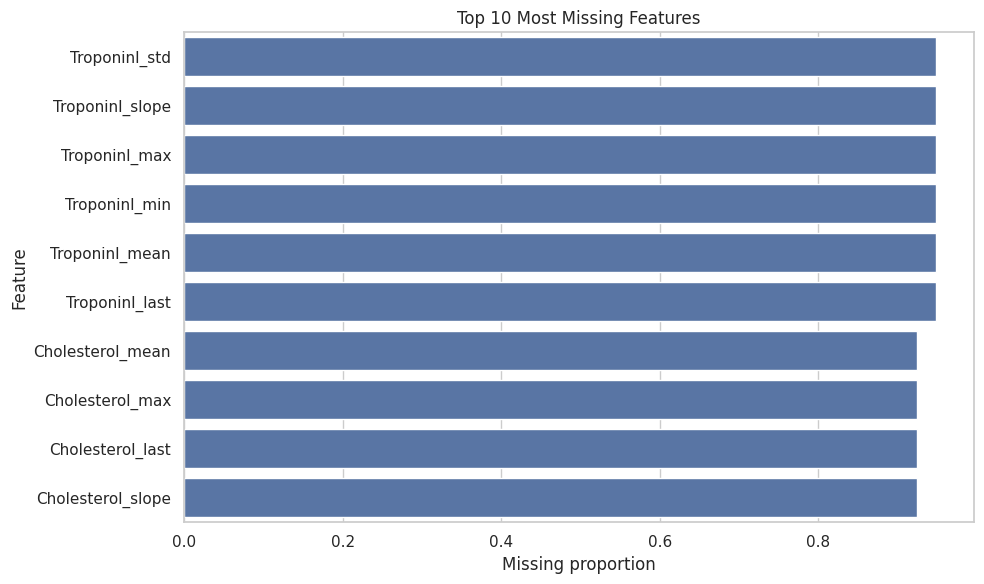

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_percent.head(10).values, y=missing_percent.head(10).index)
plt.title("Top 10 Most Missing Features")
plt.xlabel("Missing proportion")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "missingness_top10.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.2 Target Distribution

The target is imbalanced, with substantially fewer mortality cases than survivor cases.


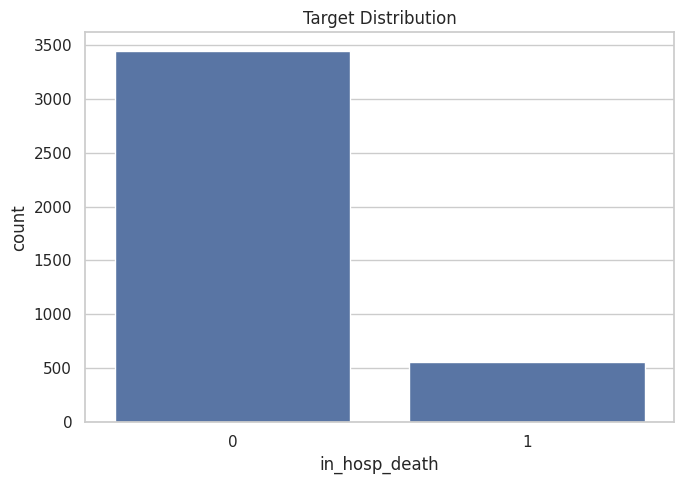

In [18]:
plt.figure(figsize=(7, 5))
sns.countplot(x="in_hosp_death", data=data)
plt.title("Target Distribution")
plt.xlabel("in_hosp_death")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.3 Example Feature Distribution

A simple check of `HR_mean` helps verify that the engineered summaries are numerically sensible.


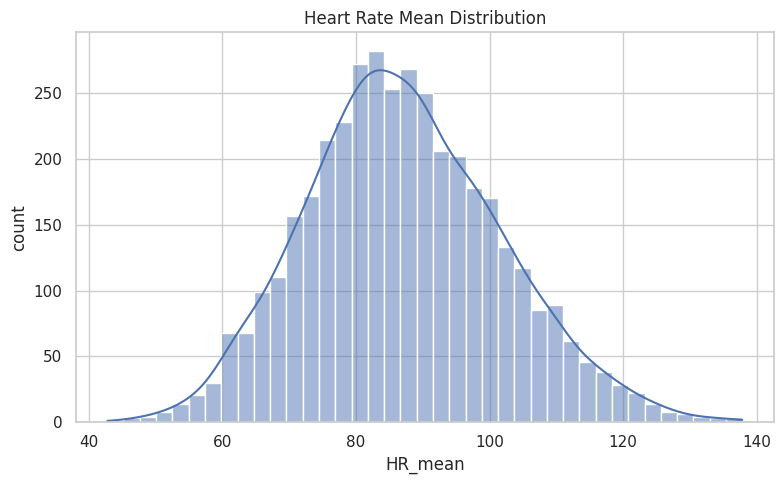

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(data["HR_mean"].dropna(), kde=True)
plt.title("Heart Rate Mean Distribution")
plt.xlabel("HR_mean")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hr_mean_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Train-test split

## 10. Train-Test Split and Modelling Setup

Median imputation is applied inside pipelines so that the imputer is fit only on training data.

ROC-AUC is used as the primary metric because the target is imbalanced and the problem is a binary risk prediction task.


In [20]:
y = data["in_hosp_death"]
X_ml = data.drop(columns=["in_hosp_death", "RecordID", "RecordID_static"], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3200, 227)
Test shape: (800, 227)


## 12. Models and comparison

## 11. Baseline Model 1 — Random Forest

Random Forest is used as a strong tabular baseline because it can model nonlinear relationships and feature interactions while remaining robust to noisy structured data.

In [21]:
rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf.fit(X_train, y_train)
rf_preds = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_preds)
print("Random Forest AUC:", rf_auc)

Random Forest AUC: 0.8676237921520941


## 12. Baseline Model 2 — XGBoost

XGBoost is expected to perform strongly on sparse, nonlinear, tabular clinical data.


In [26]:
xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    ))
])

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_preds)
print("XGBoost AUC:", xgb_auc)

XGBoost AUC: 0.8828044299742412


## 13. Baseline Model 3 — MLP

The MLP is included as a neural baseline for comparison. In this project, it is expected to be weaker than tree-based ensembles because the dataset is moderate in size, the features are engineered tabular summaries, and missingness/sparsity favour robust ensemble methods.

In [27]:
mlp_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

mlp_model.fit(X_train, y_train)
mlp_preds = mlp_model.predict_proba(X_test)[:, 1]
mlp_auc = roc_auc_score(y_test, mlp_preds)
print("MLP AUC:", mlp_auc)

MLP AUC: 0.6605211888230754


## 14. Model Comparison

This table compares held-out ROC-AUC across the three candidate models.


In [28]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "MLP"],
    "AUC": [rf_auc, xgb_auc, mlp_auc]
}).sort_values("AUC", ascending=False)

results

,Model,AUC
1,XGBoost,0.882804
0,Random Forest,0.867624
2,MLP,0.660521


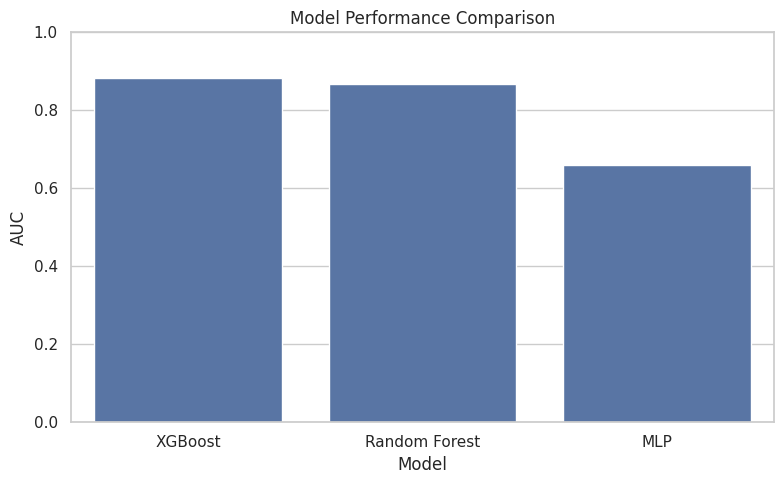

In [29]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="AUC")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Among the evaluated models, **XGBoost** achieved the strongest discrimination performance on the held-out test set, outperforming Random Forest and MLP. This suggests that gradient-boosted trees are particularly well suited to the nonlinear and sparsely observed tabular feature space derived from ICU time-series summaries.


## 13. Cross-validation and tuning


## 15. Cross-Validation for XGBoost

Five-fold cross-validation is used to assess whether the XGBoost pipeline generalises consistently across folds.


In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(xgb_model, X_ml, y, cv=cv, scoring="roc_auc", n_jobs=-1)

print("CV AUC:", scores.mean())
print("Std:", scores.std())

CV AUC: 0.8635297962648248
Std: 0.015592567871528806


## 16. Hyperparameter Tuning for XGBoost

Since XGBoost can natively handle missing values, tuning is performed directly on the estimator. The pipeline-based XGBoost model is still retained for fair baseline comparison against the other models.

In [31]:
xgb = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE)

param_dist = {
    "n_estimators": randint(200, 500),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.02, 0.18),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "min_child_weight": randint(1, 6),
    "gamma": uniform(0.0, 0.5),
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

search.fit(X_train, y_train)
best_xgb = search.best_estimator_

print("Best parameters:")
print(search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters:
{'colsample_bytree': np.float64(0.7816396748153905), 'gamma': np.float64(0.32384506027068116), 'learning_rate': np.float64(0.02009366785915685), 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 458, 'subsample': np.float64(0.7020856391593572)}


In [32]:
best_xgb_preds = best_xgb.predict_proba(X_test)[:, 1]
best_xgb_auc = roc_auc_score(y_test, best_xgb_preds)
print("Tuned XGBoost AUC:", best_xgb_auc)

Tuned XGBoost AUC: 0.8919834202853071


## 14. Metrics and ROC

## 17. Additional Evaluation Metrics

ROC-AUC remains the primary metric, but precision, recall, F1, and the confusion matrix are also reported for a threshold-based view of performance.

In [56]:
best_xgb_labels = (best_xgb_preds >= 0.3).astype(int)

print("Precision:", precision_score(y_test, best_xgb_labels, zero_division=0))
print("Recall:", recall_score(y_test, best_xgb_labels, zero_division=0))
print("F1-score:", f1_score(y_test, best_xgb_labels, zero_division=0))
print("\nClassification report:\n")
print(classification_report(y_test, best_xgb_labels, zero_division=0))

Precision: 0.6285714285714286
Recall: 0.3963963963963964
F1-score: 0.4861878453038674

Classification report:

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       689
           1       0.63      0.40      0.49       111

    accuracy                           0.88       800
   macro avg       0.77      0.68      0.71       800
weighted avg       0.87      0.88      0.87       800



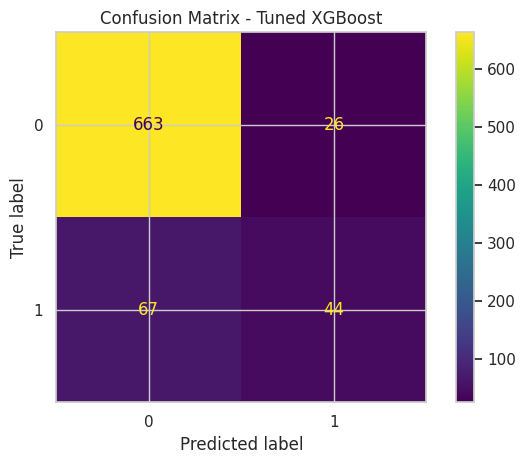

In [57]:
cm = confusion_matrix(y_test, best_xgb_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Tuned XGBoost")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_xgb.png", dpi=300, bbox_inches="tight")
plt.show()

## 18. ROC Curve Comparison

ROC curves are plotted for the main ensemble models to compare discrimination across thresholds.

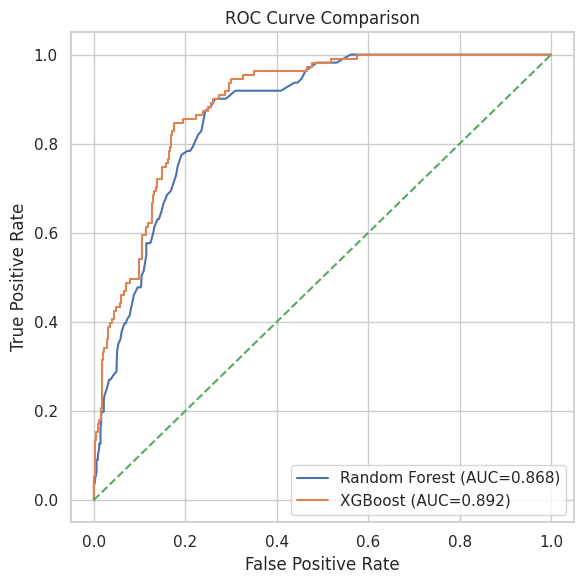

In [60]:
rf_probs = rf.predict_proba(X_test)[:, 1]
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, rf_probs):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_probs):.3f})")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Interpretability

## 19. Interpretability — SHAP Summary Plot

SHAP is used to explain how individual features contribute to the XGBoost model’s predictions. `show=False` is used before saving to avoid the common blank-image issue in Colab.

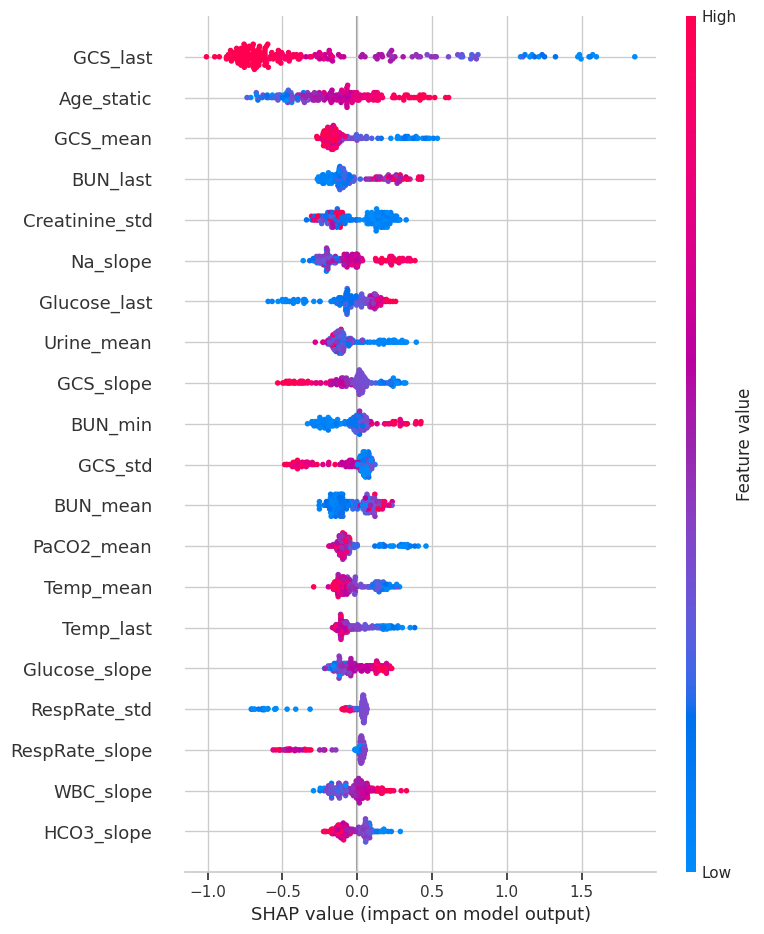

In [61]:
sample_size = min(200, len(X_test))
X_sample = X_test.sample(sample_size, random_state=RANDOM_STATE)

imputer = xgb_model.named_steps["imputer"]
X_sample_imputed = pd.DataFrame(
    imputer.transform(X_sample),
    columns=X_sample.columns,
    index=X_sample.index
)

xgb_trained = xgb_model.named_steps["model"]
explainer = shap.TreeExplainer(xgb_trained)
shap_values = explainer.shap_values(X_sample_imputed)

plt.close("all")
shap.summary_plot(shap_values, X_sample_imputed, show=False)
plt.savefig(OUTPUT_DIR / "shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 20. Interpretability — Random Forest Feature Importance

This plot highlights the most influential engineered predictors in the Random Forest model.

In [62]:
rf_model = rf.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": X_ml.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
16,GCS_last,0.037544
13,GCS_mean,0.025422
1,BUN_mean,0.019469
2,BUN_min,0.019069
18,GCS_slope,0.018162
15,GCS_max,0.017102
99,Urine_mean,0.015239
3,BUN_max,0.014518
4,BUN_last,0.014284
206,Lactate_last,0.010512


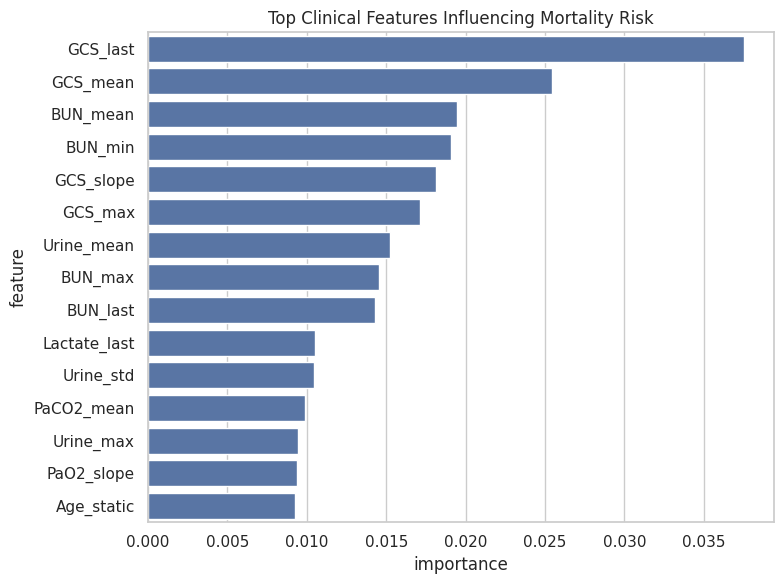

In [63]:
top_features = importance_df.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_features, y="feature", x="importance")
plt.title("Top Clinical Features Influencing Mortality Risk")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_features_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Time-window sensitivity analysis


## 21. Time-Window Sensitivity Analysis

This section tests how prediction performance changes when only the first **6h, 12h, 24h, or 48h** of ICU data are used. This experiment directly addresses the central project question: **How early can clinically useful deterioration risk prediction be achieved?**


In [64]:
def build_window_dataset(patient_files, outcomes, window_hours=48, max_patients=None):
    rows = []
    files_to_use = patient_files if max_patients is None else patient_files[:max_patients]

    for fp in tqdm(files_to_use, desc=f"Building dataset for {window_hours}h"):
        try:
            rows.append(extract_features(fp, window_hours=window_hours))
        except Exception as e:
            print(f"Skipping {fp.name} due to error: {e}")

    X_window = pd.DataFrame(rows)

    data_window = X_window.merge(
        outcomes[["recordid", "in_hosp_death"]],
        left_on="RecordID",
        right_on="recordid",
        how="inner"
    ).drop(columns=["recordid"], errors="ignore")

    return data_window

### 21.1 XGBoost Across Multiple Observation Windows

Set `TIME_WINDOW_PATIENTS` lower for quicker testing, or use `4000` for the full Set A cohort.


In [65]:
TIME_WINDOW_PATIENTS = 4000

window_results = []

for window in TIME_WINDOWS:
    data_window = build_window_dataset(
        patient_files=patient_files,
        outcomes=outcomes,
        window_hours=window,
        max_patients=TIME_WINDOW_PATIENTS
    )

    y_window = data_window["in_hosp_death"]
    X_window = data_window.drop(columns=["in_hosp_death", "RecordID", "RecordID_static"], errors="ignore")

    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
        X_window,
        y_window,
        test_size=0.2,
        stratify=y_window,
        random_state=RANDOM_STATE
    )

    scale = (y_train_w == 0).sum() / max((y_train_w == 1).sum(), 1)

    xgb_window_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale,
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ))
    ])

    xgb_window_model.fit(X_train_w, y_train_w)
    preds_w = xgb_window_model.predict_proba(X_test_w)[:, 1]
    auc_w = roc_auc_score(y_test_w, preds_w)

    window_results.append({
        "Window (hours)": window,
        "Patients": len(data_window),
        "Features": X_window.shape[1],
        "AUC": auc_w
    })

    print(f"Window {window}h | Patients={len(data_window)} | Features={X_window.shape[1]} | AUC={auc_w:.4f}")

window_results_df = pd.DataFrame(window_results)
window_results_df

Building dataset for 6h: 100%|██████████| 4000/4000 [02:39<00:00, 25.11it/s]


Window 6h | Patients=4000 | Features=227 | AUC=0.7668


Building dataset for 12h: 100%|██████████| 4000/4000 [03:07<00:00, 21.29it/s]


Window 12h | Patients=4000 | Features=227 | AUC=0.7959


Building dataset for 24h: 100%|██████████| 4000/4000 [03:33<00:00, 18.71it/s]


Window 24h | Patients=4000 | Features=227 | AUC=0.8627


Building dataset for 48h: 100%|██████████| 4000/4000 [03:51<00:00, 17.25it/s]


Window 48h | Patients=4000 | Features=227 | AUC=0.8870


,Window (hours),Patients,Features,AUC
0,6,4000,227,0.766786
1,12,4000,227,0.795918
2,24,4000,227,0.862720
3,48,4000,227,0.886976


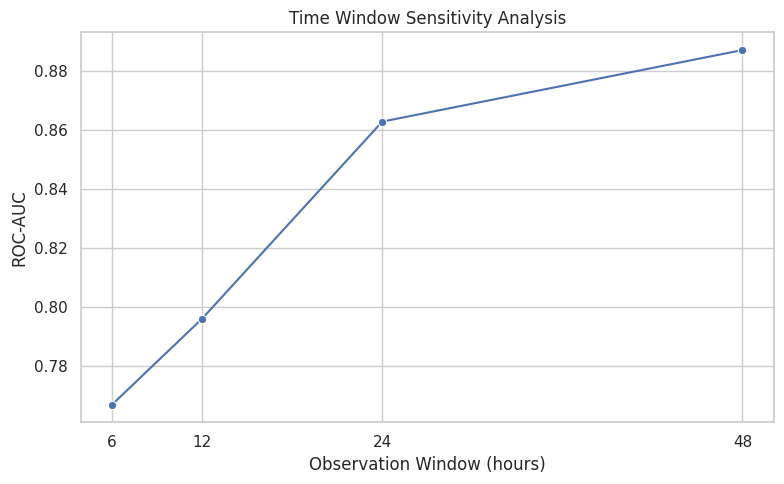

In [66]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=window_results_df, x="Window (hours)", y="AUC", marker="o")

plt.title("Time Window Sensitivity Analysis")
plt.xlabel("Observation Window (hours)")
plt.ylabel("ROC-AUC")
plt.xticks(TIME_WINDOWS)
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "time_window_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

### 21.2 Optional Comparison: Random Forest vs XGBoost by Time Window

This optional block compares two ensemble models directly across windows.

In [67]:
window_results_both = []

for window in TIME_WINDOWS:
    data_window = build_window_dataset(
        patient_files=patient_files,
        outcomes=outcomes,
        window_hours=window,
        max_patients=4000
    )

    y_window = data_window["in_hosp_death"]
    X_window = data_window.drop(columns=["in_hosp_death", "RecordID", "RecordID_static"], errors="ignore")

    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
        X_window,
        y_window,
        test_size=0.2,
        stratify=y_window,
        random_state=RANDOM_STATE
    )

    scale = (y_train_w == 0).sum() / max((y_train_w == 1).sum(), 1)

    rf_window_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])

    xgb_window_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale,
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ))
    ])

    rf_window_model.fit(X_train_w, y_train_w)
    xgb_window_model.fit(X_train_w, y_train_w)

    rf_auc_w = roc_auc_score(y_test_w, rf_window_model.predict_proba(X_test_w)[:, 1])
    xgb_auc_w = roc_auc_score(y_test_w, xgb_window_model.predict_proba(X_test_w)[:, 1])

    window_results_both.append({
        "Window (hours)": window,
        "Patients": len(data_window),
        "Features": X_window.shape[1],
        "Random Forest AUC": rf_auc_w,
        "XGBoost AUC": xgb_auc_w
    })

window_results_both_df = pd.DataFrame(window_results_both)
window_results_both_df

Building dataset for 48h: 100%|██████████| 4000/4000 [03:54<00:00, 17.06it/s]


,Window (hours),Patients,Features,Random Forest AUC,XGBoost AUC
0,6,4000,227,0.795944,0.766289
1,12,4000,227,0.807012,0.800560
2,24,4000,227,0.837982,0.862838
3,48,4000,227,0.867624,0.886466


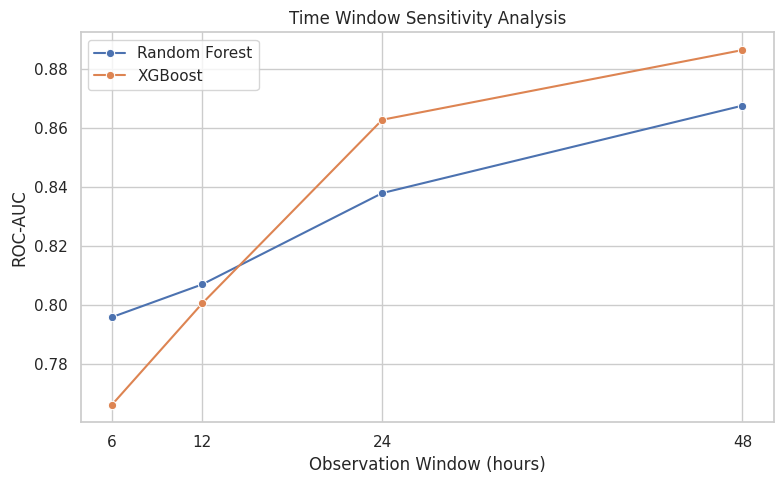

In [68]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=window_results_both_df, x="Window (hours)", y="Random Forest AUC", marker="o", label="Random Forest")
sns.lineplot(data=window_results_both_df, x="Window (hours)", y="XGBoost AUC", marker="o", label="XGBoost")

plt.title("Time Window Sensitivity Analysis")
plt.xlabel("Observation Window (hours)")
plt.ylabel("ROC-AUC")
plt.xticks(TIME_WINDOWS)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "time_window_sensitivity_both.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Save outputs

## 22. Save Key Outputs

This cell saves the main result tables for report writing and GitHub use.


In [72]:
results.to_csv(OUTPUT_DIR / "model_results.csv", index=False)
window_results_df.to_csv(OUTPUT_DIR / "time_window_results.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "rf_feature_importance.csv", index=False)
missing_percent.to_csv(OUTPUT_DIR / "missingness_profile.csv")

summary = {
    "rf_auc": float(rf_auc),
    "xgb_auc": float(xgb_auc),
    "mlp_auc": float(mlp_auc),
    "best_xgb_auc": float(best_xgb_auc),
    "cv_auc_mean": float(scores.mean()),
    "cv_auc_std": float(scores.std())
}
with open(OUTPUT_DIR / "summary_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved key outputs to:", OUTPUT_DIR)

Saved key outputs to: /content/drive/MyDrive/physionet2012/outputs


## 18. Closing markdown

## 23. Final Notes

### Main takeaways
- Early ICU measurements contain useful prognostic signal
- XGBoost provides the strongest overall discrimination
- Performance improves as more temporal context becomes available
- Interpretable features such as GCS, renal markers, and respiratory variables play an important role

